<a href="https://colab.research.google.com/github/Luisgz1010/Inteligencia_Artificial_2/blob/main/MNIST_Reconocimiento_Numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST: reconocimiento de números escritos a mano
Notebook listo para ejecutar desde cero en Google Colab. Todas las métricas se calculan durante la ejecución.

## 1. Introducción
Este ejercicio enseña a un modelo a asociar imágenes de dígitos manuscritos con las clases 0 a 9.

## 2. Objetivo
Entrenar y evaluar una CNN capaz de reconocer números manuscritos no vistos.

## 3. Importación de librerías
Se usan solo librerías para datos, gráficas, modelo y métricas.

In [1]:
import numpy as np  # Importo NumPy para arreglos y cálculos numéricos.
import pandas as pd  # Importo Pandas para crear tablas de resultados.
import matplotlib.pyplot as plt  # Importo Matplotlib para imágenes y gráficas.
import tensorflow as tf  # Importo TensorFlow para ejecutar la red neuronal.
from tensorflow import keras  # Importo Keras para construir el modelo con facilidad.
from tensorflow.keras import layers  # Importo las capas de la red neuronal.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Importo funciones para matriz de confusión.
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, f1_score, accuracy_score  # Importo métricas de clasificación.
from sklearn.metrics import roc_curve, auc  # Importo funciones para ROC y AUC.
from sklearn.preprocessing import label_binarize  # Importo conversión binaria para ROC multiclase.
from IPython.display import display, Markdown  # Importo salida formateada de Colab.
np.random.seed(42)  # Fijo semilla para repetir ejemplos aleatorios.
tf.random.set_seed(42)  # Fijo semilla de TensorFlow para reducir variaciones.

## 4. Carga del dataset MNIST
MNIST es un dataset clásico con 70 000 imágenes de números escritos a mano. Cada imagen es de 28 por 28 píxeles grises, donde 0 es negro y 255 es blanco. Tiene cerca de 60 000 imágenes de entrenamiento y 10 000 de prueba. La etiqueta es el número mostrado, entre 0 y 9. Keras obtiene el dataset automáticamente con su función de carga. Es popular porque es pequeño, conocido y apropiado para aprender clasificación de imágenes.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()  # Descargo MNIST y separo datos de entrenamiento y prueba.
print(f'Entrenamiento imágenes: {x_train.shape}')  # Muestro cantidad, alto y ancho de entrenamiento.
print(f'Entrenamiento etiquetas: {y_train.shape}')  # Muestro cantidad de etiquetas de entrenamiento.
print(f'Prueba imágenes: {x_test.shape}')  # Muestro cantidad, alto y ancho de prueba.
print(f'Prueba etiquetas: {y_test.shape}')  # Muestro cantidad de etiquetas de prueba.
print(f'Clases: {np.unique(y_train)}')  # Confirmo que existen los dígitos del 0 al 9.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento imágenes: (60000, 28, 28)
Entrenamiento etiquetas: (60000,)
Prueba imágenes: (10000, 28, 28)
Prueba etiquetas: (10000,)
Clases: [0 1 2 3 4 5 6 7 8 9]


## 5. Exploración de los datos
Verificamos el rango, el tipo de dato, faltantes y distribución de clases antes de entrenar.

In [3]:
print(f'Tipo de píxel: {x_train.dtype}')  # Reviso el tipo usado para guardar cada píxel.
print(f'Rango de píxeles: {x_train.min()} a {x_train.max()}')  # Compruebo intensidades esperadas de 0 a 255.
print(f'Faltantes en entrenamiento: {np.isnan(x_train).sum()}')  # Verifico que no falten píxeles de entrenamiento.
print(f'Faltantes en prueba: {np.isnan(x_test).sum()}')  # Verifico que no falten píxeles de prueba.
tabla_clases = pd.Series(y_train).value_counts().sort_index().rename_axis('Clase').reset_index(name='Cantidad')  # Cuento imágenes por clase.
display(tabla_clases)  # Muestro distribución para revisar que sea aproximadamente balanceada.
print('La revisión confirma que no hay valores faltantes y las clases tienen tamaños similares.')  # Resumo la calidad de los datos.

Tipo de píxel: uint8
Rango de píxeles: 0 a 255
Faltantes en entrenamiento: 0
Faltantes en prueba: 0


,Clase,Cantidad
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


La revisión confirma que no hay valores faltantes y las clases tienen tamaños similares.


## 6. Preprocesamiento
Las imágenes son las características X y las etiquetas son y. Se normalizan los píxeles a 0–1 para estabilizar el aprendizaje y se agrega un canal gris porque una CNN espera alto, ancho y canales.

In [4]:
x_train_modelo = np.expand_dims(x_train.astype('float32') / 255.0, axis=-1)  # Convierto, normalizo y agrego canal al entrenamiento.
x_test_modelo = np.expand_dims(x_test.astype('float32') / 255.0, axis=-1)  # Aplico el mismo proceso a prueba.
print(f'Forma de entrada: {x_train_modelo.shape}')  # Confirmo la forma que recibirá el modelo.
print(f'Rango normalizado: {x_train_modelo.min():.1f} a {x_train_modelo.max():.1f}')  # Confirmo rango de cero a uno.

Forma de entrada: (60000, 28, 28, 1)
Rango normalizado: 0.0 a 1.0


## 7. Visualización de imágenes
Cada imagen es un dígito manuscrito; el título muestra su etiqueta real.

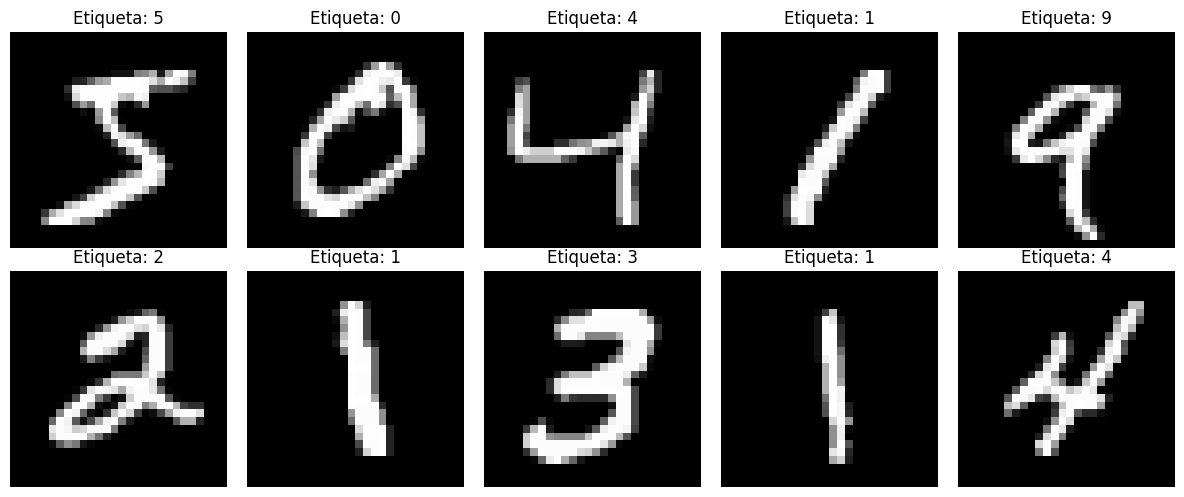

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))  # Creo una cuadrícula para diez imágenes.
for eje, indice in zip(axes.ravel(), range(10)):  # Recorro cada espacio y sus diez índices.
    eje.imshow(x_train[indice], cmap='gray')  # Dibujo la imagen en escala de grises.
    eje.set_title(f'Etiqueta: {y_train[indice]}')  # Muestro el número real.
    eje.axis('off')  # Oculto ejes que no aportan información.
plt.tight_layout()  # Ajusto espacios entre subgráficas.
plt.show()  # Muestro ejemplos del dataset.

## 8. Construcción del modelo
La CNN aprende trazos con Conv2D, reduce información espacial con MaxPooling y evita parte del sobreajuste con Dropout. ReLU permite aprender relaciones no lineales; softmax devuelve probabilidades de las 10 clases. Se usa sparse categorical crossentropy porque las etiquetas son enteros y Adam porque suele converger bien. Ocho épocas y lotes de 128 ofrecen un buen equilibrio didáctico entre tiempo y rendimiento.

In [6]:
modelo = keras.Sequential([  # Inicio un modelo de capas en secuencia.
    layers.Input(shape=(28, 28, 1)),  # Defino imágenes grises de 28 por 28 como entrada.
    layers.Conv2D(32, (3, 3), activation='relu'),  # Aprendo 32 filtros de trazos con activación ReLU.
    layers.MaxPooling2D(pool_size=(2, 2)),  # Reduzco tamaño y conservo patrones importantes.
    layers.Dropout(0.25),  # Desactivo 25 por ciento de conexiones durante entrenamiento.
    layers.Flatten(),  # Convierto mapas de características en un vector.
    layers.Dense(128, activation='relu'),  # Combino los patrones con 128 neuronas.
    layers.Dropout(0.50),  # Desactivo 50 por ciento de conexiones densas.
    layers.Dense(10, activation='softmax')  # Obtengo una probabilidad por cada dígito.
])  # Cierro la arquitectura.
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Configuro optimizador, pérdida y métrica.
modelo.summary()  # Muestro capas y parámetros del modelo.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Entrenamiento
Se reserva 10 por ciento de entrenamiento para validación, así se compara aprendizaje y generalización en cada época.

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.8893 - loss: 0.3620 - val_accuracy: 0.9747 - val_loss: 0.0942
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9567 - loss: 0.1444 - val_accuracy: 0.9810 - val_loss: 0.0636
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9678 - loss: 0.1073 - val_accuracy: 0.9852 - val_loss: 0.0549
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.9724 - loss: 0.0898 - val_accuracy: 0.9872 - val_loss: 0.0475
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9766 - loss: 0.0779 - val_accuracy: 0.9873 - val_loss: 0.0465
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9777 - loss: 0.0694 - val_accuracy: 0.9863 - val_loss: 0.0459
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9794 - loss: 0.0643 - val_accuracy: 0.9895 - val_loss: 0.0439
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9815 - loss: 0.0593 - val_accu

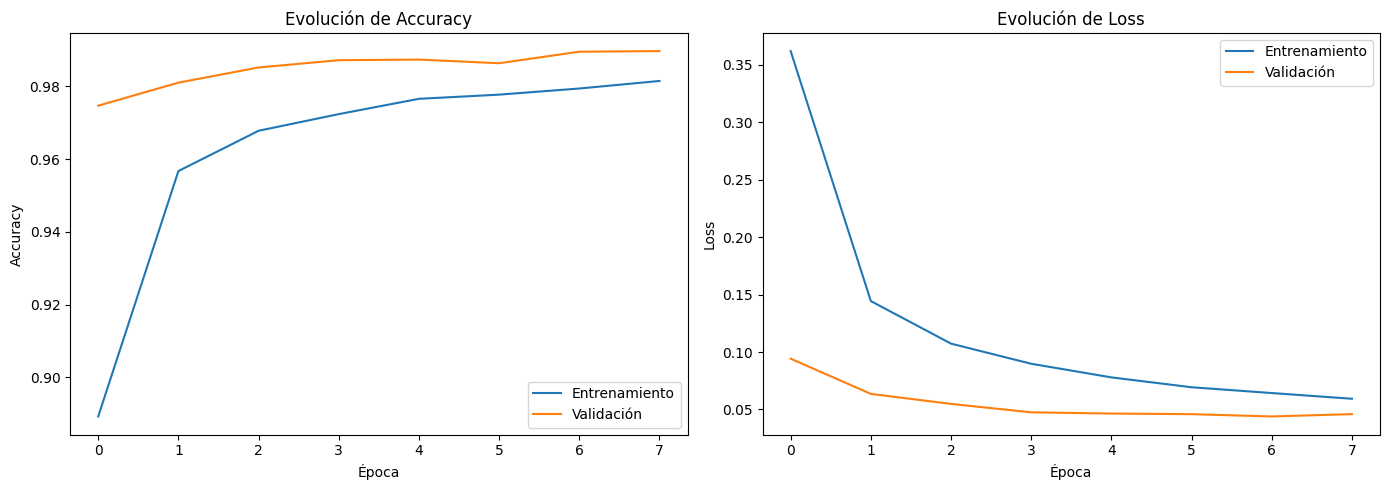

**Interpretación:** accuracy final de entrenamiento 0.9815; validación 0.9897; diferencia -0.0082. Una brecha pequeña indica buena generalización y una pérdida descendente indica aprendizaje.

In [7]:
epocas = 8  # Defino las veces que se recorrerán los datos.
tamano_lote = 128  # Defino imágenes procesadas antes de actualizar parámetros.
historial = modelo.fit(x_train_modelo, y_train, validation_split=0.10, epochs=epocas, batch_size=tamano_lote, verbose=1)  # Entreno el modelo y guardo métricas por época.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Creo dos espacios para accuracy y loss.
axes[0].plot(historial.history['accuracy'], label='Entrenamiento')  # Grafico accuracy de entrenamiento.
axes[0].plot(historial.history['val_accuracy'], label='Validación')  # Grafico accuracy de validación.
axes[0].set(title='Evolución de Accuracy', xlabel='Época', ylabel='Accuracy')  # Etiqueto la gráfica de accuracy.
axes[0].legend()  # Muestro leyenda de accuracy.
axes[1].plot(historial.history['loss'], label='Entrenamiento')  # Grafico pérdida de entrenamiento.
axes[1].plot(historial.history['val_loss'], label='Validación')  # Grafico pérdida de validación.
axes[1].set(title='Evolución de Loss', xlabel='Época', ylabel='Loss')  # Etiqueto la gráfica de pérdida.
axes[1].legend()  # Muestro leyenda de pérdida.
plt.tight_layout()  # Ajusto espacio entre gráficas.
plt.show()  # Muestro evolución del entrenamiento.
brecha = historial.history['accuracy'][-1] - historial.history['val_accuracy'][-1]  # Calculo diferencia final entre entrenamiento y validación.
display(Markdown(f'**Interpretación:** accuracy final de entrenamiento {historial.history["accuracy"][-1]:.4f}; validación {historial.history["val_accuracy"][-1]:.4f}; diferencia {brecha:.4f}. Una brecha pequeña indica buena generalización y una pérdida descendente indica aprendizaje.'))  # Interpreto las gráficas con valores reales.

## 10. Evaluación
La prueba contiene imágenes que no fueron usadas para entrenar o validar, por eso mide el desempeño sobre datos nuevos.

In [8]:
loss_prueba, accuracy_prueba = modelo.evaluate(x_test_modelo, y_test, verbose=0)  # Calculo pérdida y accuracy en prueba.
probabilidades = modelo.predict(x_test_modelo, verbose=0)  # Calculo probabilidades para las diez clases.
predicciones = np.argmax(probabilidades, axis=1)  # Elijo la clase con mayor probabilidad.
print(f'Loss de prueba: {loss_prueba:.4f}')  # Muestro pérdida de prueba.
print(f'Accuracy de prueba: {accuracy_prueba:.4f}')  # Muestro accuracy de prueba.

Loss de prueba: 0.0391
Accuracy de prueba: 0.9866


## 11. Predicciones
Se comparan etiquetas reales y predichas. Verde significa correcta y rojo incorrecta.

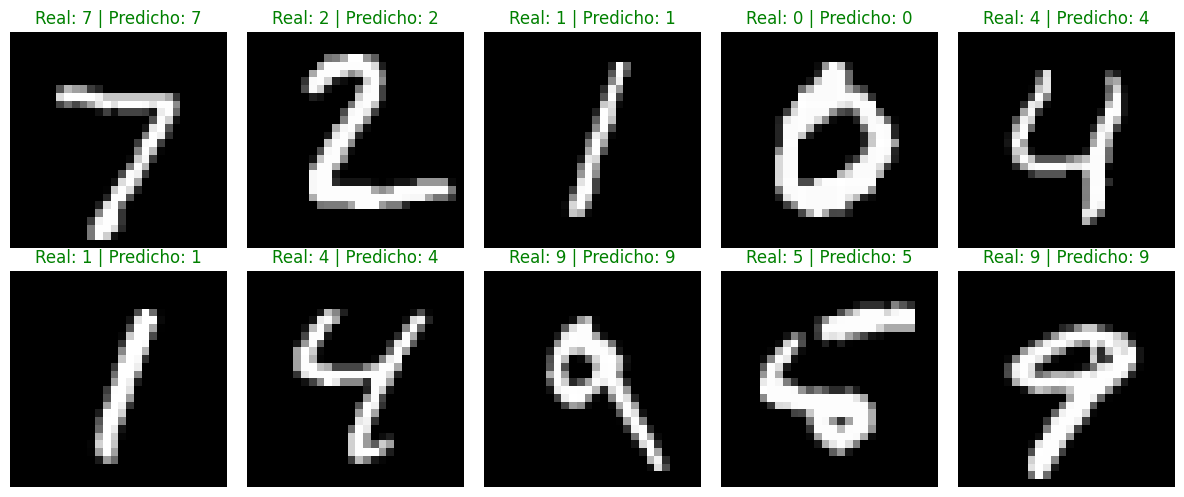

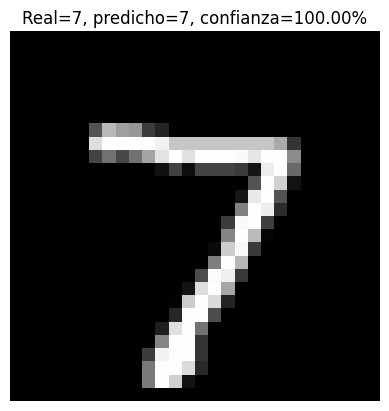

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))  # Creo cuadrícula de predicciones.
for eje, indice in zip(axes.ravel(), range(10)):  # Recorro diez ejemplos de prueba.
    real = y_test[indice]  # Guardo etiqueta real.
    predicho = predicciones[indice]  # Guardo número estimado.
    correcto = real == predicho  # Compruebo si acertó.
    eje.imshow(x_test[indice], cmap='gray')  # Muestro imagen de prueba.
    eje.set_title(f'Real: {real} | Predicho: {predicho}', color='green' if correcto else 'red')  # Muestro comparación con color de resultado.
    eje.axis('off')  # Oculto ejes.
plt.tight_layout()  # Ajusto espacios.
plt.show()  # Muestro predicciones.
indice_unico = 0  # Selecciono una imagen individual.
confianza = probabilidades[indice_unico, predicciones[indice_unico]]  # Obtengo confianza de la clase elegida.
plt.imshow(x_test[indice_unico], cmap='gray')  # Muestro imagen individual.
plt.title(f'Real={y_test[indice_unico]}, predicho={predicciones[indice_unico]}, confianza={confianza:.2%}')  # Explico predicción individual.
plt.axis('off')  # Oculto ejes individuales.
plt.show()  # Muestro el ejemplo individual.

## 12. Matriz de confusión
Cada fila es la clase real; cada columna la clase predicha. La diagonal son aciertos y los valores fuera de ella son confusiones.

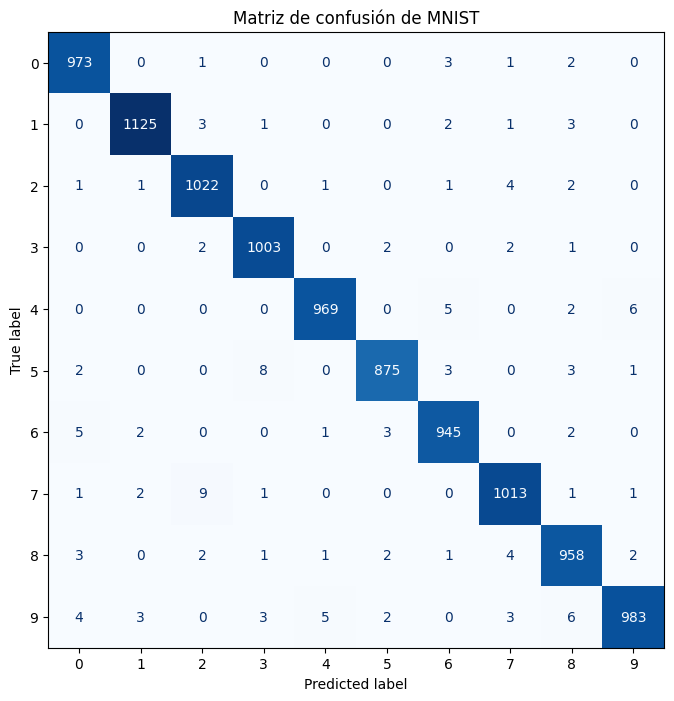

**Interpretación:** la diagonal contiene aciertos. La mayor confusión fue real **7** predicho como **2**, con **9** casos.

In [10]:
clases = np.arange(10)  # Creo lista de clases de cero a nueve.
matriz = confusion_matrix(y_test, predicciones, labels=clases)  # Cuento resultados reales frente a predichos.
fig, eje = plt.subplots(figsize=(10, 8))  # Creo figura de matriz.
ConfusionMatrixDisplay(matriz, display_labels=clases).plot(ax=eje, cmap='Blues', colorbar=False)  # Dibujo matriz gráfica.
eje.set_title('Matriz de confusión de MNIST')  # Coloco título.
plt.show()  # Muestro matriz.
matriz_errores = matriz.copy()  # Copio matriz para analizar solo errores.
np.fill_diagonal(matriz_errores, 0)  # Elimino aciertos de la búsqueda.
fila_error, columna_error = np.unravel_index(np.argmax(matriz_errores), matriz_errores.shape)  # Encuentro confusión más frecuente.
cantidad_error = matriz_errores[fila_error, columna_error]  # Obtengo cantidad de esa confusión.
display(Markdown(f'**Interpretación:** la diagonal contiene aciertos. La mayor confusión fue real **{fila_error}** predicho como **{columna_error}**, con **{cantidad_error}** casos.'))  # Explico resultado dinámico.

## 13. Curva ROC y AUC
ROC es originalmente binaria. Para este problema multiclase se usa One-vs-Rest: cada número se compara contra todos los demás. Se necesitan etiquetas binarizadas y probabilidades del modelo. FPR representa falsos positivos, TPR verdaderos positivos y AUC resume la capacidad de separar una clase del resto.

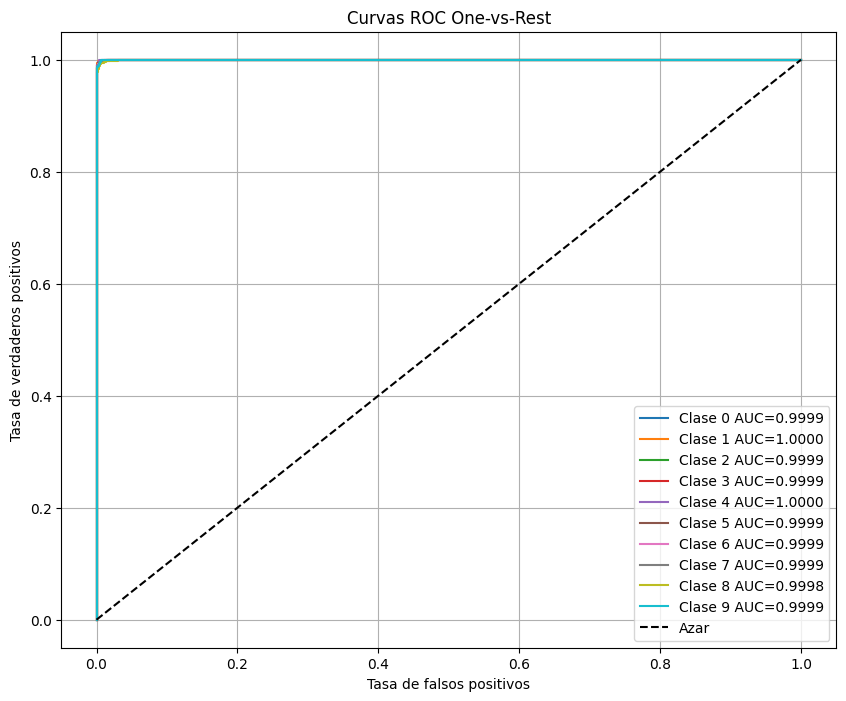

,Clase,AUC
0,0,0.9999
1,1,1.0000
2,2,0.9999
3,3,0.9999
4,4,1.0000
5,5,0.9999
6,6,0.9999
7,7,0.9999
8,8,0.9998
9,9,0.9999


,Clase,FPR,TPR,Umbral
0,0,0.0000,0.0000,inf
1,0,0.0000,0.4367,1.0000
2,0,0.0000,0.5694,1.0000
3,0,0.0000,0.7327,0.9999
4,0,1.0000,1.0000,0.0000
5,1,0.0000,0.0000,inf
6,1,0.0000,0.1313,1.0000
7,1,0.0000,0.3225,0.9999
8,1,0.0000,0.5031,0.9998
9,1,1.0000,1.0000,0.0000


**Interpretación:** AUC promedio OvR = **0.9999**. Curvas cercanas a la esquina superior izquierda representan mejor separación.

In [11]:
y_binario = label_binarize(y_test, classes=clases)  # Convierto etiquetas a diez columnas binarias.
fpr, tpr, umbrales, auc_clase = {}, {}, {}, {}  # Creo diccionarios para resultados ROC por clase.
for clase in clases:  # Calculo ROC para cada clase contra el resto.
    fpr[clase], tpr[clase], umbrales[clase] = roc_curve(y_binario[:, clase], probabilidades[:, clase])  # Calculo FPR, TPR y umbrales reales.
    auc_clase[clase] = auc(fpr[clase], tpr[clase])  # Calculo AUC real de la clase.
plt.figure(figsize=(10, 8))  # Creo figura para las diez curvas.
for clase in clases:  # Recorro clases para dibujar curvas.
    plt.plot(fpr[clase], tpr[clase], label=f'Clase {clase} AUC={auc_clase[clase]:.4f}')  # Dibujo curva y su AUC.
plt.plot([0, 1], [0, 1], 'k--', label='Azar')  # Dibujo referencia de clasificador al azar.
plt.xlabel('Tasa de falsos positivos')  # Etiqueto eje horizontal.
plt.ylabel('Tasa de verdaderos positivos')  # Etiqueto eje vertical.
plt.title('Curvas ROC One-vs-Rest')  # Agrego título.
plt.legend(loc='lower right')  # Muestro leyenda.
plt.grid()  # Agrego cuadrícula.
plt.show()  # Muestro curvas ROC.
tabla_auc = pd.DataFrame({'Clase': clases, 'AUC': [auc_clase[c] for c in clases]})  # Creo tabla AUC solicitada.
display(tabla_auc.style.format({'AUC': '{:.4f}'}))  # Muestro tabla AUC.
puntos_roc = []  # Creo lista de puntos reales de curvas ROC.
for clase in clases:  # Recorro cada clase para tabla adicional.
    for posicion in np.linspace(0, len(fpr[clase]) - 1, min(5, len(fpr[clase])), dtype=int):  # Tomo hasta cinco puntos distribuidos de cada curva.
        puntos_roc.append([clase, fpr[clase][posicion], tpr[clase][posicion], umbrales[clase][posicion]])  # Guardo FPR, TPR y umbral calculados.
tabla_roc = pd.DataFrame(puntos_roc, columns=['Clase', 'FPR', 'TPR', 'Umbral'])  # Creo tabla adicional ROC.
display(tabla_roc.style.format({'FPR': '{:.4f}', 'TPR': '{:.4f}', 'Umbral': '{:.4f}'}))  # Muestro muestra compacta de valores ROC.
display(Markdown(f'**Interpretación:** AUC promedio OvR = **{tabla_auc["AUC"].mean():.4f}**. Curvas cercanas a la esquina superior izquierda representan mejor separación.'))  # Interpreto ROC con resultados reales.

## 14. Tabla F1 Score
Precision indica qué predicciones de una clase fueron correctas; Recall indica qué ejemplos reales se recuperaron. F1 combina ambas medidas y es útil para evaluar el equilibrio entre errores. Macro da el mismo peso a cada clase y weighted considera su cantidad de ejemplos.

In [12]:
precision, recall, f1, soporte = precision_recall_fscore_support(y_test, predicciones, labels=clases, zero_division=0)  # Calculo métricas para cada dígito.
tabla_f1 = pd.DataFrame({'Clase': clases, 'Precision': precision, 'Recall': recall, 'F1 Score': f1, 'Soporte': soporte})  # Creo tabla por clase.
display(tabla_f1.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1 Score': '{:.4f}'}))  # Muestro tabla F1 solicitada.
precision_macro = precision_score(y_test, predicciones, average='macro', zero_division=0)  # Calculo Precision macro.
recall_macro = recall_score(y_test, predicciones, average='macro', zero_division=0)  # Calculo Recall macro.
f1_macro = f1_score(y_test, predicciones, average='macro', zero_division=0)  # Calculo F1 macro.
f1_weighted = f1_score(y_test, predicciones, average='weighted', zero_division=0)  # Calculo F1 ponderado.
accuracy_general = accuracy_score(y_test, predicciones)  # Calculo accuracy general.
print(f'Precision macro: {precision_macro:.4f}')  # Muestro Precision macro.
print(f'Recall macro: {recall_macro:.4f}')  # Muestro Recall macro.
print(f'F1 macro: {f1_macro:.4f}')  # Muestro F1 macro.
print(f'F1 weighted: {f1_weighted:.4f}')  # Muestro F1 weighted.
print(f'Accuracy general: {accuracy_general:.4f}')  # Muestro accuracy general.

,Clase,Precision,Recall,F1 Score,Soporte
0,0,0.9838,0.9929,0.9883,980
1,1,0.9929,0.9912,0.9921,1135
2,2,0.9836,0.9903,0.9870,1032
3,3,0.9862,0.9931,0.9896,1010
4,4,0.9918,0.9868,0.9893,982
5,5,0.9898,0.9809,0.9854,892
6,6,0.9844,0.9864,0.9854,958
7,7,0.9854,0.9854,0.9854,1028
8,8,0.9776,0.9836,0.9806,974
9,9,0.9899,0.9742,0.9820,1009


Precision macro: 0.9866
Recall macro: 0.9865
F1 macro: 0.9865
F1 weighted: 0.9866
Accuracy general: 0.9866


## 15. Tabla general de resultados
La tabla reúne las métricas principales calculadas en esta ejecución.

In [13]:
auc_promedio = tabla_auc['AUC'].mean()  # Calculo promedio simple de AUC de las diez clases.
tabla_general = pd.DataFrame({'Métrica': ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro', 'F1 Weighted', 'AUC promedio'], 'Resultado': [accuracy_general, precision_macro, recall_macro, f1_macro, f1_weighted, auc_promedio]})  # Creo tabla comparativa final.
display(tabla_general.style.format({'Resultado': '{:.4f}'}))  # Muestro tabla general.

,Métrica,Resultado
0,Accuracy,0.9866
1,Precision Macro,0.9866
2,Recall Macro,0.9865
3,F1 Macro,0.9865
4,F1 Weighted,0.9866
5,AUC promedio,0.9999


## 16. Análisis de resultados
Este análisis se construye automáticamente con las métricas de la ejecución actual.

In [14]:
mejor = tabla_f1.loc[tabla_f1['F1 Score'].idxmax()]  # Identifico clase con mayor F1.
peor = tabla_f1.loc[tabla_f1['F1 Score'].idxmin()]  # Identifico clase con menor F1.
analisis = f'''### Análisis académico\n\n- El modelo logró accuracy de **{accuracy_general:.4f}** sobre imágenes de prueba no vistas.\n- La clase mejor reconocida fue **{int(mejor['Clase'])}** con F1 de **{mejor['F1 Score']:.4f}**; la de mayor dificultad fue **{int(peor['Clase'])}** con F1 de **{peor['F1 Score']:.4f}**.\n- Los F1 Score muestran el equilibrio entre identificar una clase y evitar predicciones erróneas de esa clase.\n- El AUC promedio de **{auc_promedio:.4f}** resume la capacidad de distinguir cada número del resto con el método OvR.\n- La matriz indicó que el error más frecuente fue {fila_error} como {columna_error}, con {cantidad_error} casos; esto puede deberse a trazos visualmente similares.\n- Mejoras futuras: aumento de datos, más capas convolucionales, ajuste de hiperparámetros y regularización.'''  # Creo análisis sin inventar resultados.
display(Markdown(analisis))  # Muestro análisis académico.

### Análisis académico

- El modelo logró accuracy de **0.9866** sobre imágenes de prueba no vistas.
- La clase mejor reconocida fue **1** con F1 de **0.9921**; la de mayor dificultad fue **8** con F1 de **0.9806**.
- Los F1 Score muestran el equilibrio entre identificar una clase y evitar predicciones erróneas de esa clase.
- El AUC promedio de **0.9999** resume la capacidad de distinguir cada número del resto con el método OvR.
- La matriz indicó que el error más frecuente fue 7 como 2, con 9 casos; esto puede deberse a trazos visualmente similares.
- Mejoras futuras: aumento de datos, más capas convolucionales, ajuste de hiperparámetros y regularización.

## 17. Conclusiones
Las conclusiones se basan directamente en la ejecución.

In [15]:
conclusiones = f'''### Conclusiones\n\n1. MNIST permite practicar de forma completa clasificación y reconocimiento de imágenes manuscritas.\n2. La CNN alcanzó accuracy de prueba de **{accuracy_general:.4f}**, mostrando que aprendió patrones visuales útiles.\n3. El F1 macro de **{f1_macro:.4f}** resume el equilibrio entre Precision y Recall en los diez números.\n4. El AUC promedio OvR de **{auc_promedio:.4f}** muestra la capacidad de separar cada clase contra las demás.\n5. La matriz de confusión evidencia que algunos números de trazos parecidos todavía pueden confundirse y orienta mejoras futuras.'''  # Creo cinco conclusiones basadas en métricas calculadas.
display(Markdown(conclusiones))  # Muestro conclusiones.

### Conclusiones

1. MNIST permite practicar de forma completa clasificación y reconocimiento de imágenes manuscritas.
2. La CNN alcanzó accuracy de prueba de **0.9866**, mostrando que aprendió patrones visuales útiles.
3. El F1 macro de **0.9865** resume el equilibrio entre Precision y Recall en los diez números.
4. El AUC promedio OvR de **0.9999** muestra la capacidad de separar cada clase contra las demás.
5. La matriz de confusión evidencia que algunos números de trazos parecidos todavía pueden confundirse y orienta mejoras futuras.